In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, accuracy_score,roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay

In [2]:

df = pd.read_csv("WineQT.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [3]:

df.quality.value_counts()

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

In [4]:

print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())


Shape: (1143, 13)

Missing values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


---
#### Create binary label: Good (>=7) vs Bad (<7)
---

In [5]:

df["quality"] >= 7

0       False
1       False
2       False
3       False
4       False
        ...  
1138    False
1139    False
1140    False
1141    False
1142    False
Name: quality, Length: 1143, dtype: bool

In [6]:

df["label"] = (df["quality"] >= 7).astype(int)

In [7]:

print(df["label"])

0       0
1       0
2       0
3       0
4       0
       ..
1138    0
1139    0
1140    0
1141    0
1142    0
Name: label, Length: 1143, dtype: int32


In [8]:

print(df["label"].value_counts())

label
0    984
1    159
Name: count, dtype: int64


---
    (df["quality"] >= 7) → produces a boolean mask (True if quality ≥ 7, else False).
    
    .astype(int) → converts True → 1 (Good) and False → 0 (Bad).
    
    Now it is binary target, hence suitable for SVM classification.
---

In [9]:

df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,label
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,0
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,0
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,0
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,0


In [10]:

X = df.drop(columns=["Id", "quality", "label"], errors="ignore")

X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2


In [11]:

y = df["label"]

y

0       0
1       0
2       0
3       0
4       0
       ..
1138    0
1139    0
1140    0
1141    0
1142    0
Name: label, Length: 1143, dtype: int32

In [12]:

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:

basic_svm = SVC(probability=True, random_state=42)  

basic_svm.fit(X_train_scaled, y_train) 

SVC(probability=True, random_state=42)

In [15]:

y_pred_basic = basic_svm.predict(X_test_scaled)

y_prob_basic = basic_svm.predict_proba(X_test_scaled)[:, 1]

In [16]:

y_pred_basic 

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0])

In [17]:

y_prob_basic

array([0.3723382 , 0.70728589, 0.11907566, 0.0371395 , 0.07561064,
       0.10443437, 0.45396173, 0.0506428 , 0.12355432, 0.06205927,
       0.73791061, 0.1698007 , 0.06205927, 0.06287566, 0.05041533,
       0.87555824, 0.07920589, 0.06438656, 0.0722678 , 0.01746811,
       0.05520841, 0.12230553, 0.06143437, 0.05863497, 0.06323135,
       0.04025076, 0.0576532 , 0.0505309 , 0.02713976, 0.06294318,
       0.12071115, 0.0672341 , 0.14265174, 0.07083799, 0.04018737,
       0.0332607 , 0.10980749, 0.07417927, 0.03700778, 0.05986996,
       0.06087408, 0.0596177 , 0.2520365 , 0.08110183, 0.03357851,
       0.07425183, 0.05404337, 0.06478951, 0.05307777, 0.07446194,
       0.08488998, 0.12029188, 0.05844926, 0.10451924, 0.06081275,
       0.22204303, 0.06826858, 0.06341102, 0.08961608, 0.12186369,
       0.54987069, 0.04366696, 0.13507836, 0.07187499, 0.07344745,
       0.14790972, 0.0308176 , 0.86829101, 0.06502634, 0.02063108,
       0.05890954, 0.1188831 , 0.05594528, 0.07078766, 0.03437

In [18]:

print("Accuracy:", accuracy_score(y_test, y_pred_basic))

Accuracy: 0.8995633187772926


In [19]:

print("ROC AUC:", roc_auc_score(y_test, y_pred_basic))

ROC AUC: 0.6929727157360407


In [20]:

print("\nClassification Report:\n", classification_report(y_test, y_pred_basic))


Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94       197
           1       0.76      0.41      0.53        32

    accuracy                           0.90       229
   macro avg       0.84      0.69      0.74       229
weighted avg       0.89      0.90      0.89       229



In [21]:

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_basic))

Confusion Matrix:
 [[193   4]
 [ 19  13]]


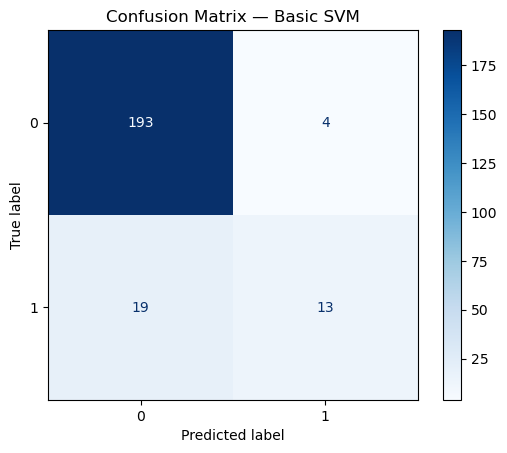

In [22]:

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_basic, cmap="Blues")

plt.title("Confusion Matrix — Basic SVM")
plt.show()

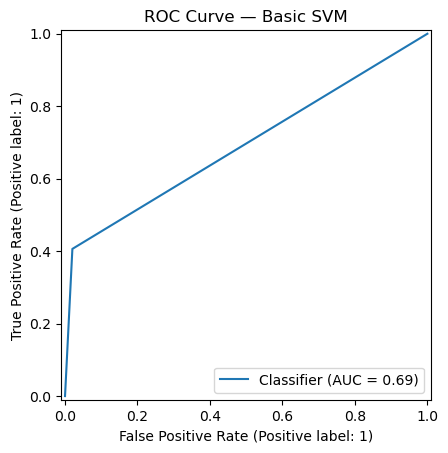

In [23]:

RocCurveDisplay.from_predictions(y_test, y_pred_basic)

plt.title("ROC Curve — Basic SVM")
plt.show()


### Hyper Param Tune


In [24]:

param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"],
    "kernel": ["linear", "rbf", "poly"]
}

grid = GridSearchCV(SVC(probability=True, random_state=42),
                    param_grid, refit=True, cv=5, scoring="accuracy")
grid.fit(X_train_scaled, y_train)

svm_best = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [26]:

y_pred = svm_best.predict(X_test_scaled)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.95       197
           1       0.78      0.44      0.56        32

    accuracy                           0.90       229
   macro avg       0.85      0.71      0.75       229
weighted avg       0.90      0.90      0.89       229

Confusion Matrix:
 [[193   4]
 [ 18  14]]
Accuracy: 0.9039301310043668



### Model Comparision  with baseline and Tuned Model


In [27]:

from sklearn.metrics import roc_auc_score

# Baseline metrics
baseline_acc = accuracy_score(y_test, y_pred_basic)
baseline_auc = roc_auc_score(y_test, y_prob_basic)

# Tuned metrics
y_prob_tuned = svm_best.predict_proba(X_test_scaled)[:, 1]
tuned_acc = accuracy_score(y_test, y_pred)
tuned_auc = roc_auc_score(y_test, y_prob_tuned)


print(f"Baseline SVM -> Accuracy: {baseline_acc:.3f}, ROC AUC: {baseline_auc:.3f}")
print(f"Tuned SVM    -> Accuracy: {tuned_acc:.3f}, ROC AUC: {tuned_auc:.3f}")


Baseline SVM -> Accuracy: 0.900, ROC AUC: 0.850
Tuned SVM    -> Accuracy: 0.904, ROC AUC: 0.873


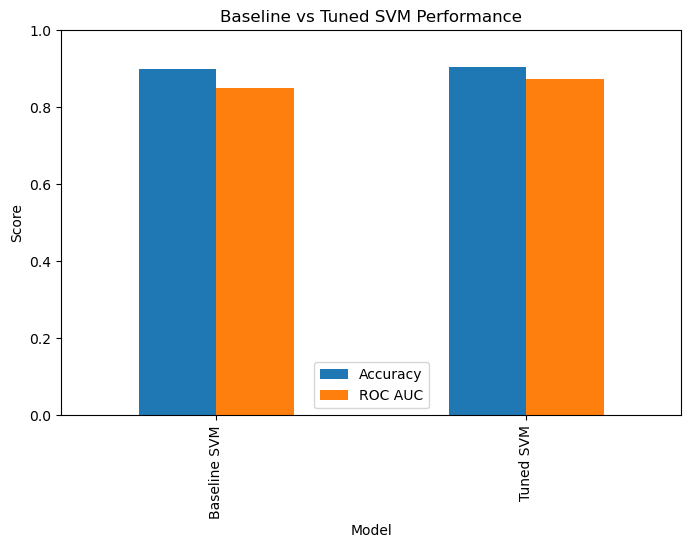

In [28]:

import pandas as pd

results = pd.DataFrame({
    "Model": ["Baseline SVM", "Tuned SVM"],
    "Accuracy": [baseline_acc, tuned_acc],
    "ROC AUC": [baseline_auc, tuned_auc]
})

results.set_index("Model")[["Accuracy", "ROC AUC"]].plot(kind="bar", ylim=(0,1), figsize=(8,5))
plt.title("Baseline vs Tuned SVM Performance")
plt.ylabel("Score")
plt.show()


### Comparitive study with various Kernals

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.exceptions import NotFittedError

kernels = ["linear", "rbf", "poly", "sigmoid"]

results = []

for kernel in kernels:
    print(f"\n===== Kernel: {kernel.upper()} =====")
    
    model = SVC(kernel=kernel, probability=True, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    print("Accuracy:", acc)
    print("ROC AUC:", auc)

    print(classification_report(y_test, y_pred, zero_division=0))
    
    results.append((kernel, acc, auc))

results_df = pd.DataFrame(results, columns=["Kernel", "Accuracy", "ROC_AUC"])

results_df


===== Kernel: LINEAR =====
Accuracy: 0.8602620087336245
ROC AUC: 0.8110723350253807
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       197
           1       0.00      0.00      0.00        32

    accuracy                           0.86       229
   macro avg       0.43      0.50      0.46       229
weighted avg       0.74      0.86      0.80       229


===== Kernel: RBF =====
Accuracy: 0.8995633187772926
ROC AUC: 0.8497779187817259
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       197
           1       0.76      0.41      0.53        32

    accuracy                           0.90       229
   macro avg       0.84      0.69      0.74       229
weighted avg       0.89      0.90      0.89       229


===== Kernel: POLY =====
Accuracy: 0.8908296943231441
ROC AUC: 0.8494606598984772
              precision    recall  f1-score   support

           0       0.90      0.98      0.

,Kernel,Accuracy,ROC_AUC
0,linear,0.860262,0.811072
1,rbf,0.899563,0.849778
2,poly,0.890830,0.849461
3,sigmoid,0.816594,0.755393


### Kernel Comparison Results 

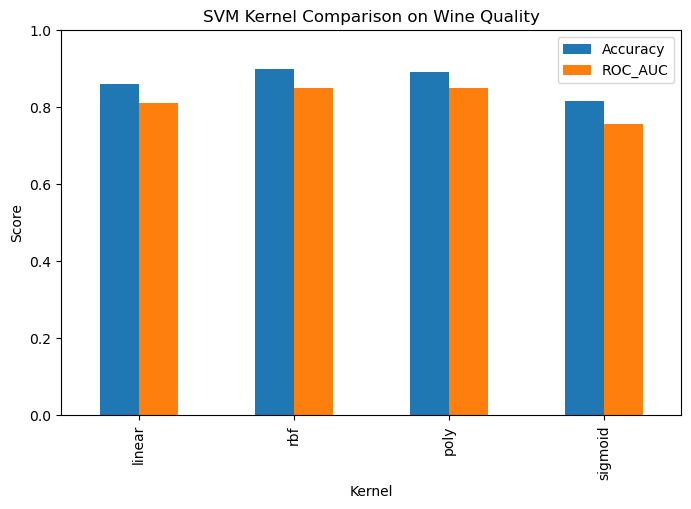

In [30]:

results_df.set_index("Kernel")[["Accuracy", "ROC_AUC"]].plot(kind="bar", figsize=(8,5), ylim=(0,1))
plt.title("SVM Kernel Comparison on Wine Quality")
plt.ylabel("Score")
plt.show()